In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sns as sns

In [2]:
# Loading classification tools from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [6]:
# Loading the dataset and dropping missing values
df = pd.read_csv('Auto.csv', na_values='?')
df = df.dropna().reset_index(drop=True)
print(f"Dataset loaded successfully. Shape: {df.shape}")

Dataset loaded successfully. Shape: (392, 9)


### A) Creating the Binary Variable

In [9]:
mpg_median = df['mpg'].median()
print(f"The median MPG is: {mpg_median}")

# Create binary column: 1 if above median, 0 if below/equal
df['mpg01'] = (df['mpg'] > mpg_median).astype(int)

print("\nClass distribution in mpg01:")
print(df['mpg01'].value_counts())


The median MPG is: 22.75

Class distribution in mpg01:
mpg01
0    196
1    196
Name: count, dtype: int64


### B) Graphical Data Exploration

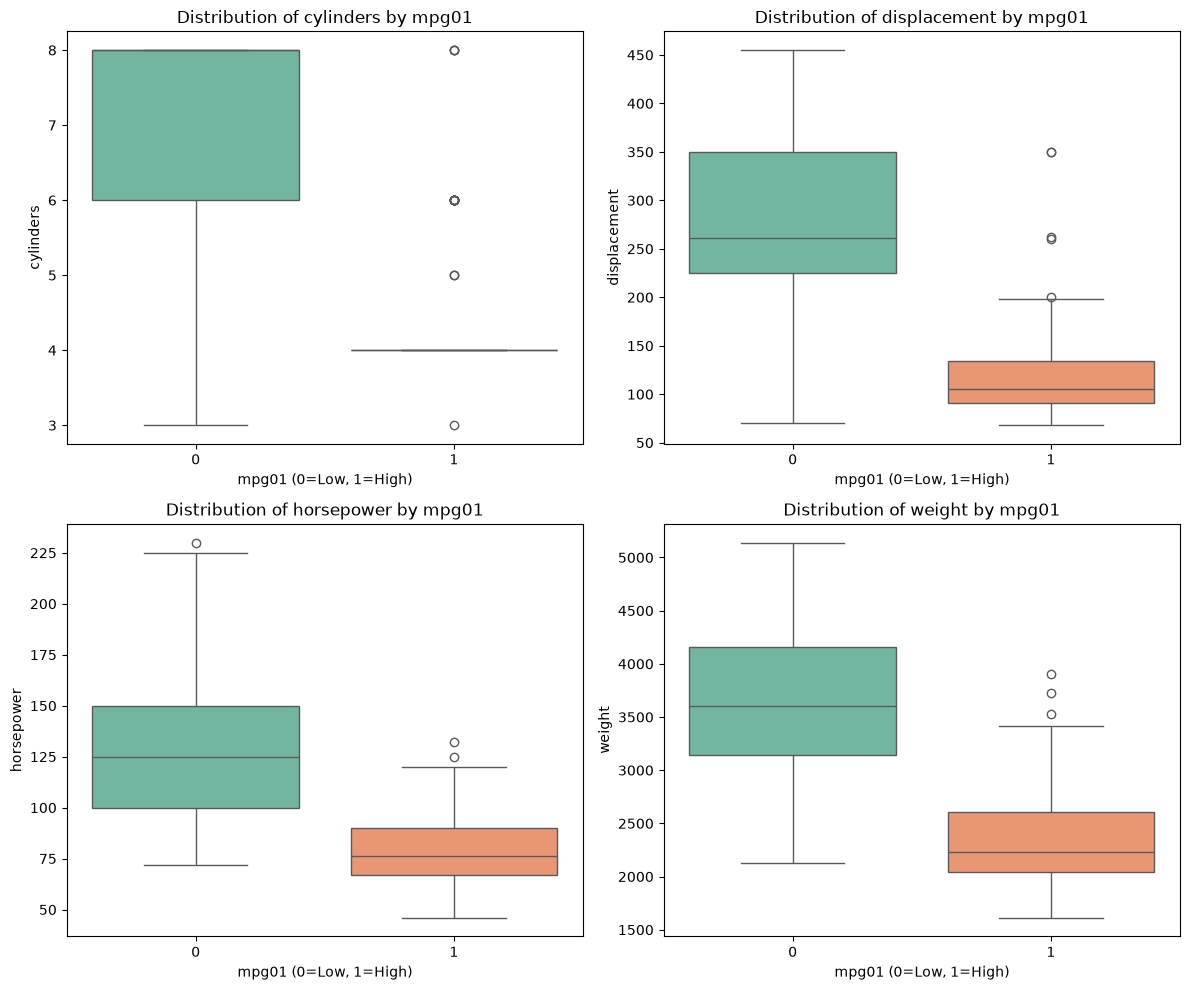

In [20]:
import seaborn as sns
# Select key features to evaluate against our new binary target
features_to_plot = ['cylinders', 'displacement', 'horsepower', 'weight']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.boxplot(data=df, x='mpg01', y=col, ax=axes[i], palette='Set2', hue='mpg01', legend=False)
    axes[i].set_title(f'Distribution of {col} by mpg01')
    axes[i].set_xlabel('mpg01 (0=Low, 1=High)')

plt.tight_layout()
plt.show()

### C) Splitting the Dataset

In [23]:
X = df[['cylinders', 'displacement', 'horsepower', 'weight']]
y = df['mpg01']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size: {X_test.shape[0]} rows")


Training set size: 313 rows
Testing set size: 79 rows


### (D-G) Training the Parametric Models

In [26]:
# Models inside a python dictionary dictionary
models = {
    "Linear Discriminant Analysis (LDA)": LDA(),
    "Quadratic Discriminant Analysis (QDA)": QDA(),
    "Logistic Regression": LogisticRegression(solver='liblinear'),
    "Naive Bayes (Gaussian)": GaussianNB()
}
for name, model in models.items():
    model.fit(X_train, y_train)   
    test_accuracy = model.score(X_test, y_test)
    test_error = 1 - test_accuracy
    print(f"{name}: Test Error Rate = {test_error:.4f} ({test_error*100:.2f}%)")


Linear Discriminant Analysis (LDA): Test Error Rate = 0.1013 (10.13%)
Quadratic Discriminant Analysis (QDA): Test Error Rate = 0.1013 (10.13%)
Logistic Regression: Test Error Rate = 0.1266 (12.66%)
Naive Bayes (Gaussian): Test Error Rate = 0.1139 (11.39%)


### E) - Tuning the K-Nearest Neighbors (KNN) Classifier

--- KNN Neighborhood Parameter Tuning ---
KNN (K= 1): Test Error Rate = 0.1646 (16.46%)
KNN (K= 3): Test Error Rate = 0.0759 (7.59%)
KNN (K= 5): Test Error Rate = 0.1139 (11.39%)
KNN (K= 7): Test Error Rate = 0.1139 (11.39%)
KNN (K=10): Test Error Rate = 0.1139 (11.39%)
KNN (K=15): Test Error Rate = 0.1392 (13.92%)
KNN (K=20): Test Error Rate = 0.1519 (15.19%)
KNN (K=30): Test Error Rate = 0.1266 (12.66%)


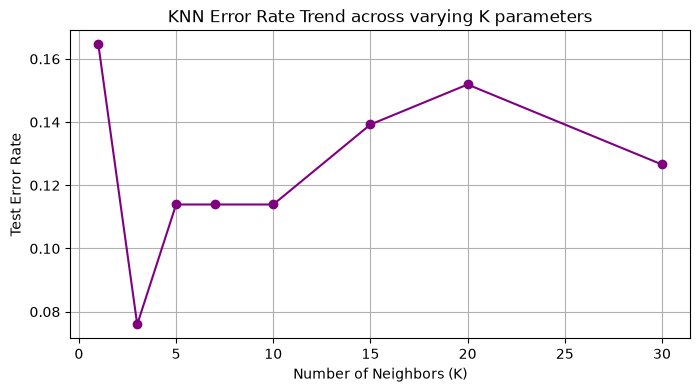

In [29]:
# Range of neighbors 
k_values = [1, 3, 5, 7, 10, 15, 20, 30]
knn_errors = []

print("--- KNN Neighborhood Parameter Tuning ---")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    
    # Error Calculation
    error = 1 - knn.score(X_test, y_test)
    knn_errors.append(error)
    print(f"KNN (K={k:2d}): Test Error Rate = {error:.4f} ({error*100:.2f}%)")

# Error rate trend
plt.figure(figsize=(8, 4))
plt.plot(k_values, knn_errors, marker='o', linestyle='-', color='purple')
plt.title('KNN Error Rate Trend across varying K parameters')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Test Error Rate')
plt.grid(True)
plt.show()
